# Project 3 Dean Callahan Tree Biomass Prediction (KNN Model)



This notebook demonstrates my KNN model for predicting tree biomass using tree data from LegacyTreeData v2 (subset of NSVB_tree.csv dataset). This subset contains three field measurements which will be used to predict tree biomass: diameter, height, and species.


In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_squared_log_error
from sklearn.preprocessing import StandardScaler
from scipy import stats
from mpl_toolkits.mplot3d import Axes3D
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)


## 1. Import Data and Preview



In [26]:
from google.colab import drive
drive.mount('/content/drive')

df=pd.read_csv("/content/drive/MyDrive/DATA 311 Redwood Analytics/Project 3/biomass_model_dataset.csv")
print(df.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   SPCD  DO_BH  HT_TOT  TT_DW_CRM
0    12    7.5    45.2     178.86
1    12    9.3    62.7     323.46
2    12    9.7    56.7     342.47
3    12   11.4    66.1     499.35
4    12    6.4    51.8     113.92


## 2. Data Dictionary

- SPCD (FIA Species Code): A numeric code which unqiuely identifies each tree species and corresponds to a scientific and common name for the tree as specified by the FIA (Forest Inventory and Analysis) species coding system.

- DO_BH (Diameter at Breast Height): Diameter of the tree stem measured at breast height (4.5 feet or 1.37 meters above ground) including bark. This is the standard foresty measurement "DBH (outside bark)" and is the primary size variable used in nearly all allometric biomass models. This is measured in **inches**.

- HT_TOT (Total Tree Height): The total height of the tree measured from ground level to the top of the crown. Used as a second size metric in volume and biomass modeling. This is measured in **feet**.

- TT_DW_CRM (Total Tree Dry Biomass): The total above-ground dry weight of the tree (includes stem wood, stem bark, branches, folliage). The value comes from destructive sampling: the tree was felled, separated into componenets, oven-dried, and weighed. This variable serves as the target variable from biomass prediction. Measured in **kilograms**.


## 2. Exploratory Data Summaries and Visualizations

In [27]:
 df_visuals=pd.read_csv("/content/drive/MyDrive/DATA 311 Redwood Analytics/Project 3/biomass_model_dataset.csv")
 full_species_codes=pd.read_csv("/content/drive/MyDrive/DATA 311 Redwood Analytics/Project 3/FIATreeSpeciesCode.csv")
 species_codes=full_species_codes[["SPCD","COMMON_NAME"]]
 df_visuals=df.merge(species_codes,on='SPCD', how='left')
 df_visuals.head()


,SPCD,DO_BH,HT_TOT,TT_DW_CRM,COMMON_NAME
0,12,7.5,45.2,178.86,balsam fir
1,12,9.3,62.7,323.46,balsam fir
2,12,9.7,56.7,342.47,balsam fir
3,12,11.4,66.1,499.35,balsam fir
4,12,6.4,51.8,113.92,balsam fir


In [28]:
#General data summary
print(f"\nSummary Statistics")
print(df.describe())


Summary Statistics
                SPCD          DO_BH         HT_TOT     TT_DW_CRM
count  137079.000000  137079.000000  137079.000000  1.370790e+05
mean      341.054465      11.104809      62.081565  1.530719e+03
std       341.609599       8.046896      25.834963  1.698299e+04
min        10.000000       1.000000       1.400000  1.020000e+00
25%       121.000000       6.500000      45.000000  1.689850e+02
50%       132.000000       9.900000      61.100000  5.276000e+02
75%       611.000000      14.300000      76.700000  1.352070e+03
max      8768.000000     334.900000     379.300000  1.385886e+06


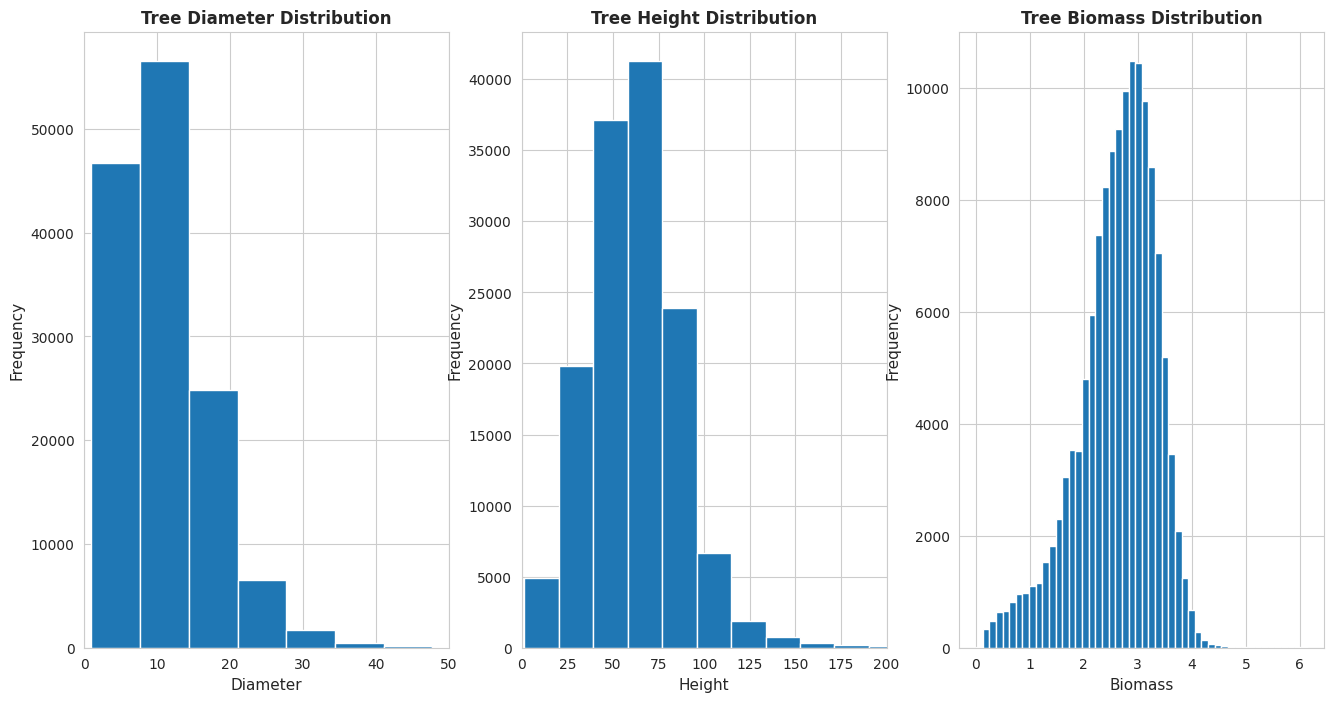

In [29]:
#Univariate Visulizations & Summaries
#Plot the diameter distribution
fig, axes = plt.subplots(1, 3, figsize=(16, 8))
axes[0].hist(df_visuals['DO_BH'],bins=50)
axes[0].set_xlim(0,50)
axes[0].set_xlabel('Diameter', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].set_title('Tree Diameter Distribution', fontsize=12, fontweight='bold')

#Plot the height distribution
axes[1].hist(df_visuals['HT_TOT'],bins=20)
axes[1].set_xlim(0,200)
axes[1].set_xlabel('Height', fontsize=11)
axes[1].set_ylabel('Frequency', fontsize=11)
axes[1].set_title('Tree Height Distribution', fontsize=12, fontweight='bold')

#Plot the biomass distribution
log_biomass = np.log10(df_visuals['TT_DW_CRM'])
axes[2].hist(log_biomass,bins=50)
axes[2].set_xlabel('Biomass', fontsize=11)
axes[2].set_ylabel('Frequency', fontsize=11)
axes[2].set_title('Tree Biomass Distribution', fontsize=12, fontweight='bold')
plt.show()

In [30]:
#Univariate for SPCD (using corresponding common name instead for readibility)
df_visuals["COMMON_NAME"].value_counts().head(10)

,count
COMMON_NAME,
loblolly pine,20140
slash pine,8006
Douglas-fir,7322
ponderosa pine,5609
shortleaf pine,5599
longleaf pine,4949
white oak,3955
sweetgum,3494
yellow-poplar,3372


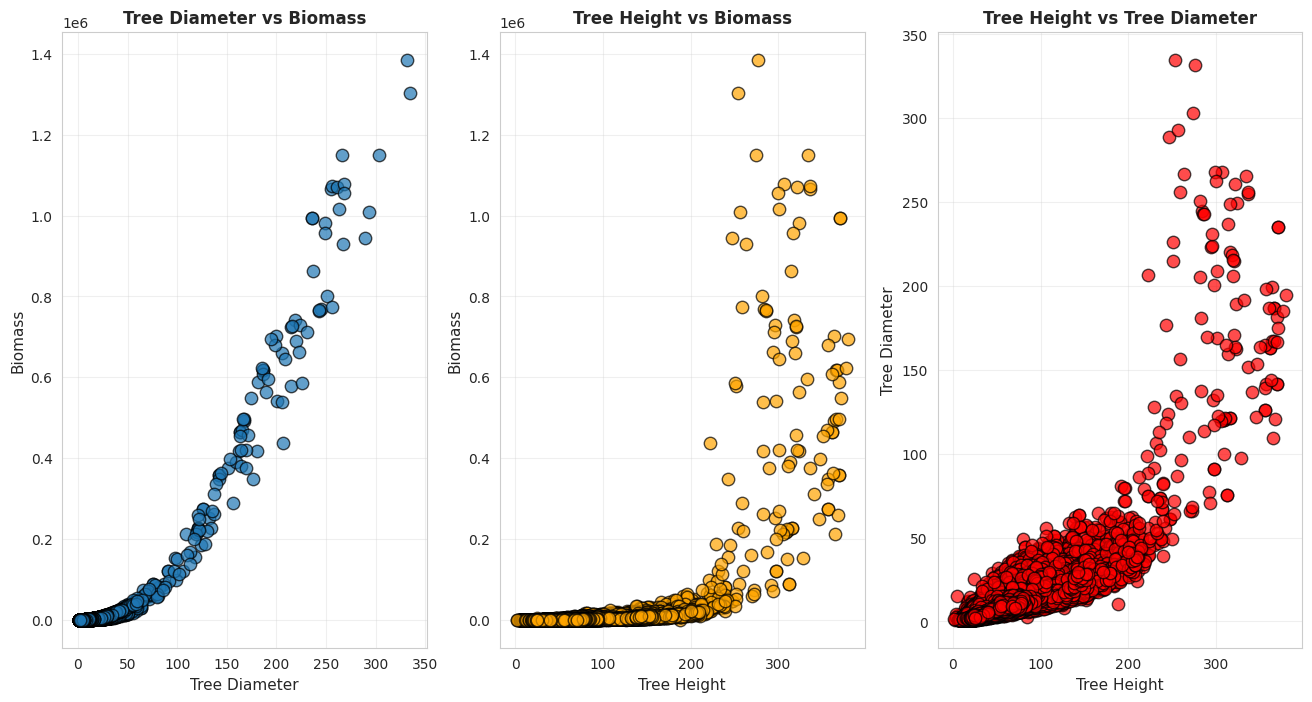

In [31]:
#Bivariate Visualizations

# Figure 1 plots Diameter vs Biomass
fig, axes = plt.subplots(1, 3, figsize=(16, 8))
axes[0].scatter(df_visuals['DO_BH'], df_visuals['TT_DW_CRM'], alpha=0.7, s=80, edgecolors='black')
axes[0].set_xlabel('Tree Diameter', fontsize=11)
axes[0].set_ylabel('Biomass', fontsize=11)
axes[0].set_title('Tree Diameter vs Biomass', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Figure 2 plots Height vs Biomass
axes[1].scatter(df_visuals['HT_TOT'], df_visuals['TT_DW_CRM'], alpha=0.7, s=80, edgecolors='black', color='orange')
axes[1].set_xlabel('Tree Height', fontsize=11)
axes[1].set_ylabel('Biomass', fontsize=11)
axes[1].set_title('Tree Height vs Biomass', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Figure 1 plots Height vs Diameter
axes[2].scatter(df_visuals['HT_TOT'], df_visuals['DO_BH'], alpha=0.7, s=80, edgecolors='black', color='red')
axes[2].set_xlabel('Tree Height', fontsize=11)
axes[2].set_ylabel('Tree Diameter', fontsize=11)
axes[2].set_title('Tree Height vs Tree Diameter', fontsize=12, fontweight='bold')
axes[2].grid(True, alpha=0.3)

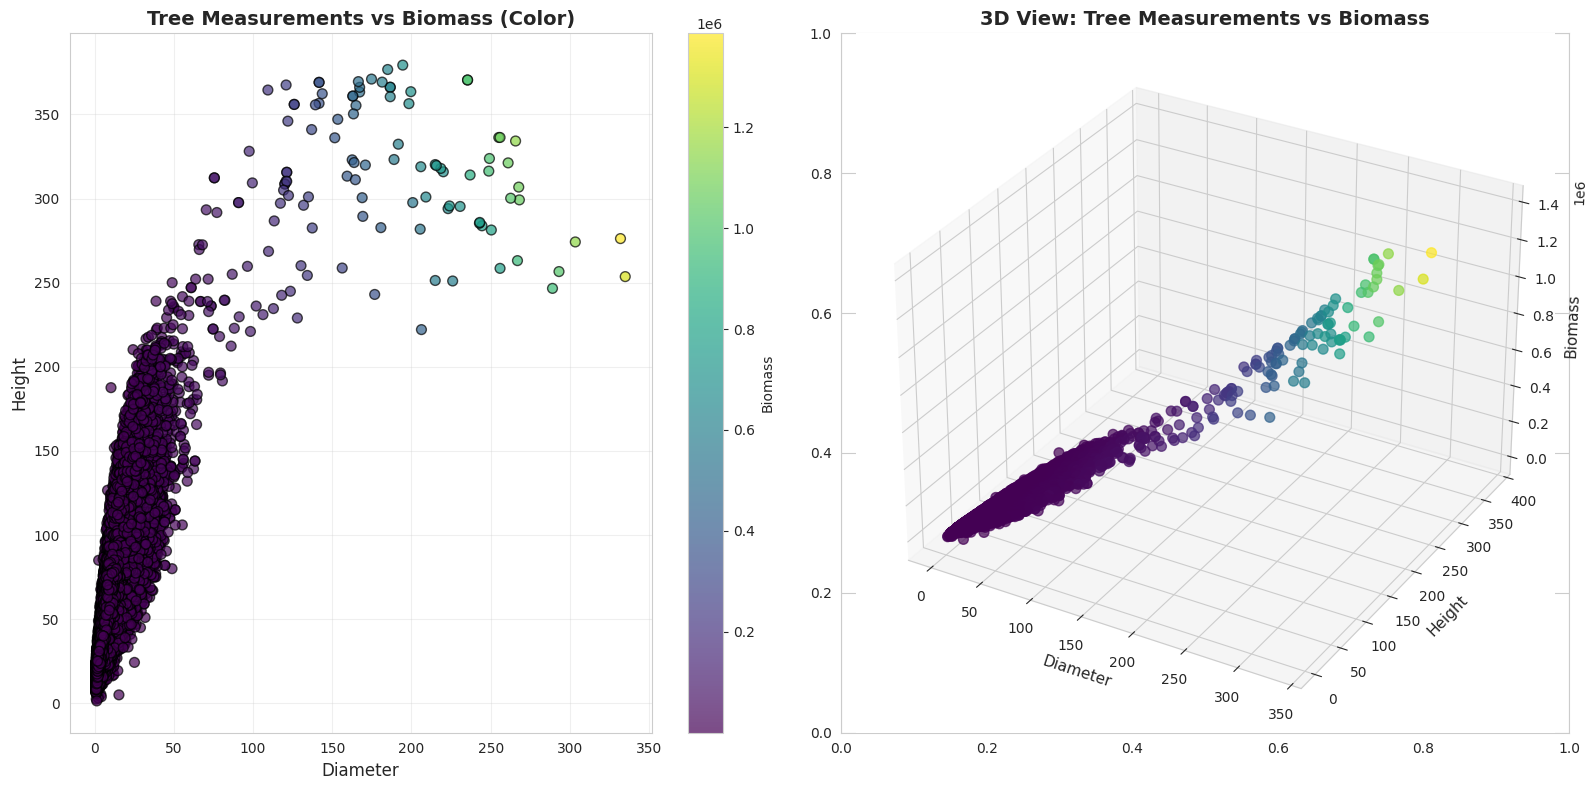

In [32]:
 #combined vars vs biomass 3d view
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Left: Scatter plot colored by tree biomass
scatter = axes[0].scatter(df['DO_BH'], df['HT_TOT'], c=df['TT_DW_CRM'],
                         cmap='viridis', s=50, alpha=0.7, edgecolors='black')
axes[0].set_xlabel('Diameter', fontsize=12)
axes[0].set_ylabel('Height', fontsize=12)
axes[0].set_title('Tree Measurements vs Biomass (Color)', fontsize=14, fontweight='bold')
plt.colorbar(scatter, ax=axes[0], label='Biomass')
axes[0].grid(True, alpha=0.3)

# Right: 3D relationship (DO_BH, HT_TOT, TT_DW_CRM)
ax = fig.add_subplot(122, projection='3d')
scatter3d = ax.scatter(df['DO_BH'], df['HT_TOT'], df['TT_DW_CRM'],
                      c=df['TT_DW_CRM'], cmap='viridis', s=50, alpha=0.7)
ax.set_xlabel('Diameter', fontsize=11)
ax.set_ylabel('Height', fontsize=11)
ax.set_zlabel('Biomass', fontsize=11)
ax.set_title('3D View: Tree Measurements vs Biomass', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

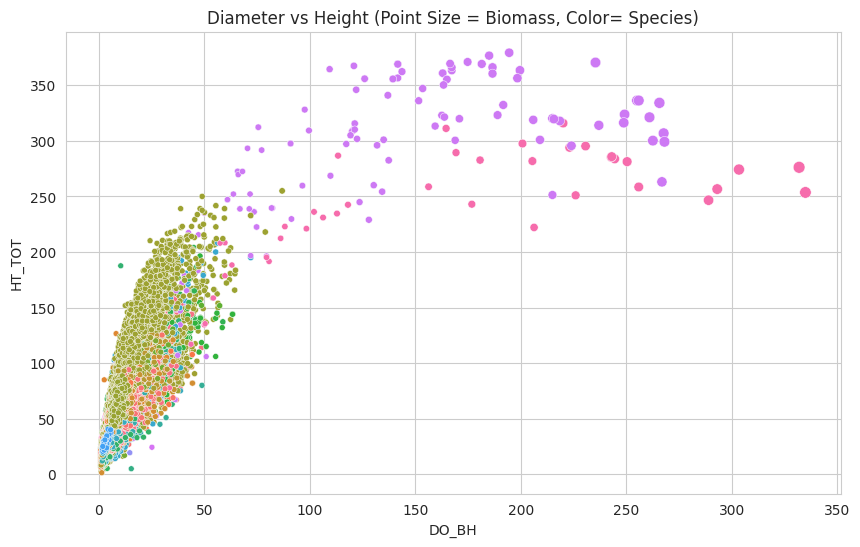

In [33]:
#Visualization Containing all 4 Variables
sns.scatterplot(data=df_visuals, x='DO_BH',y='HT_TOT',hue='COMMON_NAME',size='TT_DW_CRM',legend=False)
plt.title("Diameter vs Height (Point Size = Biomass, Color= Species)")
plt.show()

## 4. Fit KNN model

In [34]:
# Load training, testing, and selection (validation) datasets
training_df = pd.read_csv("/content/drive/MyDrive/DATA 311 Redwood Analytics/Project 3/training_data.csv")
testing_df = pd.read_csv("/content/drive/MyDrive/DATA 311 Redwood Analytics/Project 3/testing_data.csv")
selection_df = pd.read_csv("/content/drive/MyDrive/DATA 311 Redwood Analytics/Project 3/selection_data.csv")

# Lists to store RMSLE values for each species
RMSLE_TEST = []
RMSLE_SELECTION = []

# Loop through each species in the dataset
for name in training_df["COMMON_NAME"].unique():

  # Extract subset of data for the current species (building a new model for each species in the dataset)
  train = training_df[training_df['COMMON_NAME']==name]
  test = testing_df[testing_df['COMMON_NAME']==name]
  selection = selection_df[selection_df['COMMON_NAME']==name]

  # Use DO_BH and HT_TOT as predictor variables and TT_DW_CRM as the target variable
  X_train = train[['DO_BH','HT_TOT']]
  y_train = train['TT_DW_CRM']
  X_test = test[['DO_BH', 'HT_TOT']]
  y_test = test['TT_DW_CRM']
  X_selection = selection[['DO_BH','HT_TOT']]
  y_selection = selection['TT_DW_CRM']

  #Scale the features
  scaler = StandardScaler()
  X_train_scaled = scaler.fit_transform(X_train)
  X_test_scaled = scaler.transform(X_test)
  X_selection_scaled = scaler.transform(X_selection)

  # Train KNN model (k = 3)
  k = 3
  knn = KNeighborsRegressor(n_neighbors=k)
  knn.fit(X_train_scaled, y_train)

  # Evaluate on TEST dataset
  y_pred_test = knn.predict(X_test_scaled)
  rmsle_test = np.sqrt(mean_squared_log_error(y_test, y_pred_test))

  # Store (species name, RMSLE value)
  RMSLE_TEST.append((name, rmsle_test))

  # Evaluate on SELECTION dataset
  y_pred_selection = knn.predict(X_selection_scaled)
  rmsle_selection = np.sqrt(mean_squared_log_error(y_selection, y_pred_selection))

  # Store (species name, RMSLE value)
  RMSLE_SELECTION.append((name, rmsle_selection))

In [35]:
#Display the RMSLE for each species models in the selection dataset
rmsle_df_selection = pd.DataFrame(RMSLE_SELECTION, columns=['COMMON_NAME', 'RMSLE'])
print(rmsle_df_selection.to_string(index=False))

                COMMON_NAME    RMSLE
                balsam fir  0.165870
         eastern white pine 0.125481
            eastern hemlock 0.181361
                  red maple 0.173159
                sugar maple 0.187862
               yellow birch 0.297353
                  white ash 0.226170
                  black ash 0.329483
             bigtooth aspen 0.171048
              quaking aspen 0.145939
           northern red oak 0.155630
          American basswood 0.255011
                  jack pine 0.106070
                   red pine 0.120403
                paper birch 0.553637
              balsam poplar 0.252115
             shortleaf pine 0.189968
             pignut hickory 0.252216
               black cherry 0.188781
                scarlet oak 0.141976
                   post oak 0.160784
                  black oak 0.155439
                  white oak 0.135746
               white spruce 0.130473
               black spruce 0.167712
       northern white-cedar 0.099025
 

<BarContainer object of 100 artists>

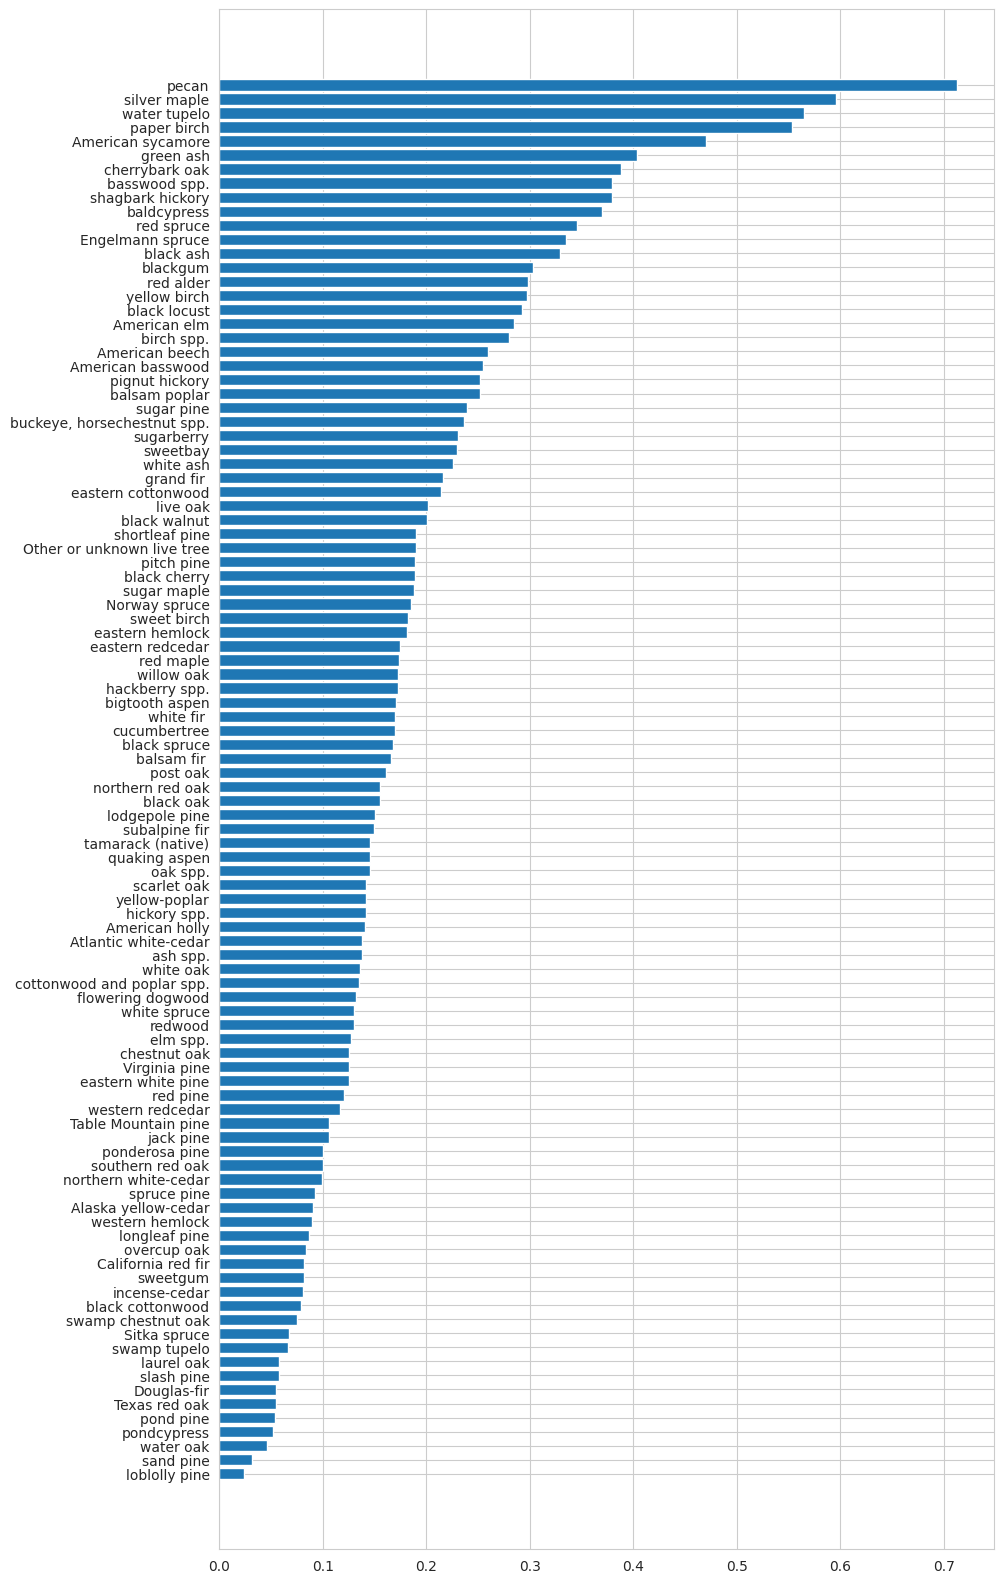

In [36]:
#Visualize the RMSLE for each species models in the selection dataset (can see pecan has highest RMSLE and loblolly pine has lowest RMSLE)
rmsle_df_selection=rmsle_df_selection.sort_values('RMSLE',ascending=True)
rmsle_df_selection
plt.figure(figsize=(10, 20))
plt.barh(rmsle_df_selection['COMMON_NAME'],rmsle_df_selection['RMSLE'])

<BarContainer object of 41 artists>

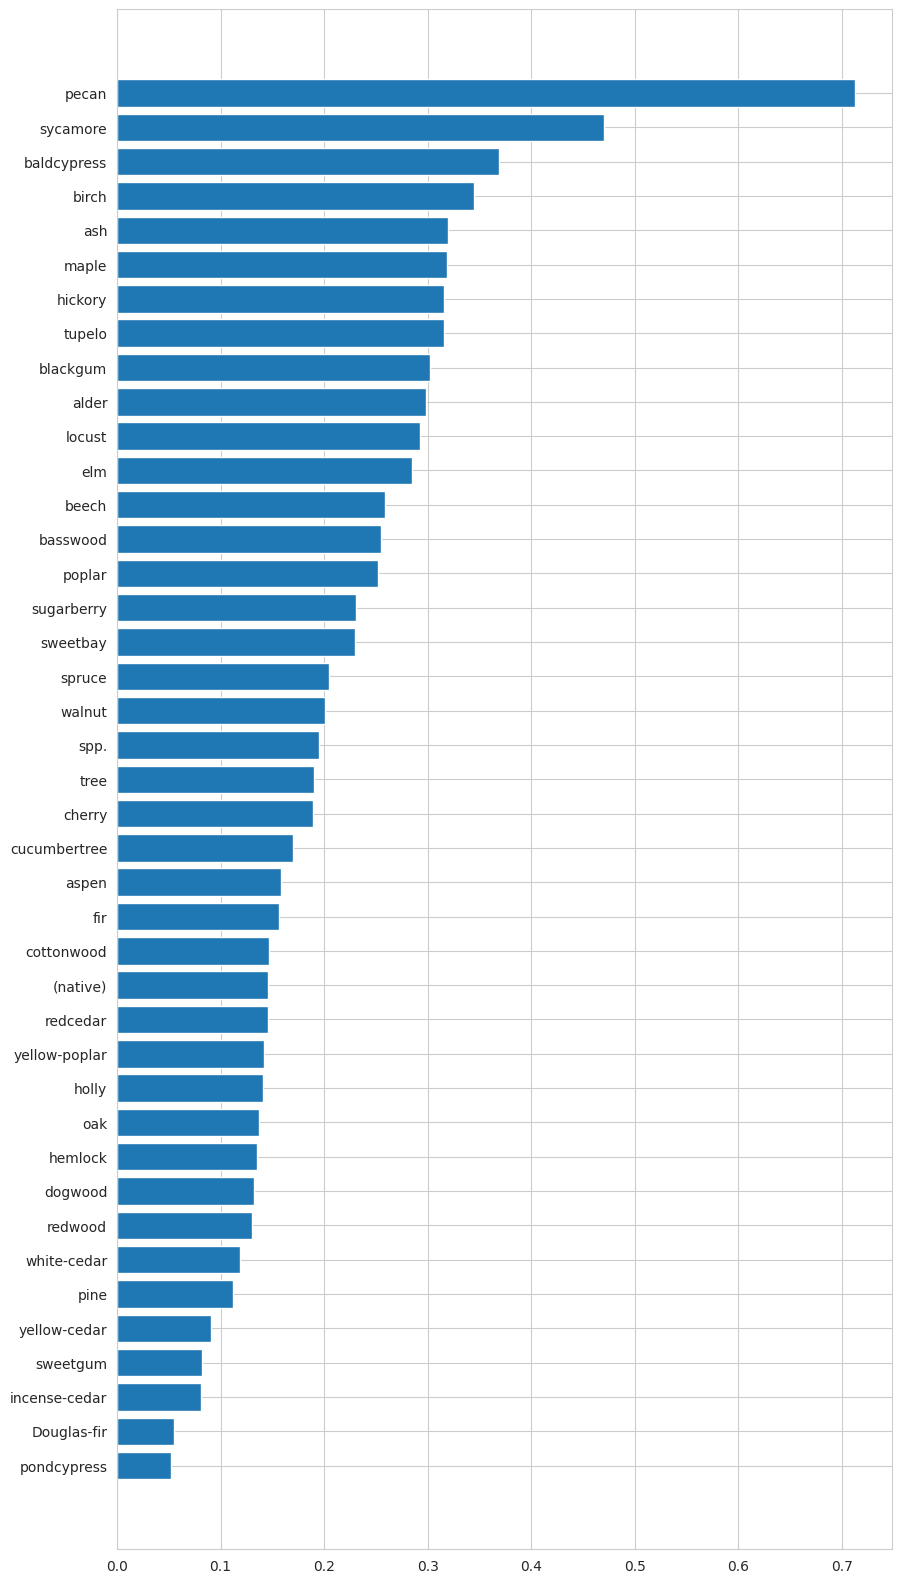

In [37]:
#Visualize the RMSLE for each general species models in the selection dataset grouping by last word in common name
rmsle_df_selection["GROUP"] = rmsle_df_selection["COMMON_NAME"].str.split().str[-1]
rmsle_df_selection["GROUP"].unique()
grouped = rmsle_df_selection.groupby("GROUP")["RMSLE"].mean().sort_values()
grouped
plt.figure(figsize=(10, 20))
plt.barh(grouped.index,grouped.values)

In [38]:
#Compute the average RMSLE for our model on the validation dataset. This is the number we will compare to chose the best model in our group.
rmsle_df_selection['RMSLE'].mean()

np.float64(0.18999080589332007)

In [39]:
#Display the RMSLE for each species models in the test dataset
rmsle_df_test = pd.DataFrame(RMSLE_TEST, columns=['COMMON_NAME', 'RMSLE'])
print(rmsle_df_test.to_string(index=False))

                COMMON_NAME    RMSLE
                balsam fir  0.123746
         eastern white pine 0.131025
            eastern hemlock 0.196506
                  red maple 0.103740
                sugar maple 0.223838
               yellow birch 0.196006
                  white ash 0.292819
                  black ash 0.123011
             bigtooth aspen 0.106754
              quaking aspen 0.078667
           northern red oak 0.129594
          American basswood 0.188086
                  jack pine 0.075951
                   red pine 0.202294
                paper birch 0.252399
              balsam poplar 0.155614
             shortleaf pine 0.135564
             pignut hickory 0.280976
               black cherry 0.216810
                scarlet oak 0.150088
                   post oak 0.133523
                  black oak 0.128815
                  white oak 0.126183
               white spruce 0.143270
               black spruce 0.119676
       northern white-cedar 0.153965
 

In [40]:
#Compute the average RMSLE for our model on the test dataset
rmsle_df_test['RMSLE'].mean()

np.float64(0.15808192537990745)

# Testing for valid input domain


In [41]:
# Make a data summary to get the input valid ranges from our training dataset
training_df.describe()

,SPCD,DO_BH,HT_TOT,TT_DW_CRM
count,107646.000000,107646.000000,107646.000000,1.076460e+05
mean,333.299593,11.136514,62.261863,1.243523e+03
std,285.765562,6.718127,24.363731,8.631558e+03
min,12.000000,1.000000,2.500000,1.020000e+00
25%,121.000000,6.700000,46.000000,1.803650e+02
50%,132.000000,10.100000,62.000000,5.569100e+02
75%,611.000000,14.400000,77.000000,1.383040e+03
max,999.000000,255.900000,370.500000,1.073456e+06


## Model Inputs & Domains:
- **SPCD:** FIA species code (categorical). Valid species only include species in the dataset with a count greater than 100.
- **DO_BH:** Diameter at breast height, measured in **inches**. Valid Range: 1.0-255.9 inches (based on training data)
- **HT_TOT:** Total tree height, measured in **feet**. Valid Range: 2.5-370.5 feet

## Output:
- **TT_DW_CRM**: Total above-ground dry biomass in **kilograms**


# Model Limitations:
- Will not work for less frequent species in the dataset or species that don't appear in it
- May work very well for some species or poorly for others:
-RMSLE of 0.037176 for Sweetgum vs RMSLE of 0.666503 for Shagbark hickory
- k=3: Lower k value may lead to overfitting of data due to potential outliers and noise
